# Predicting Appliance Energy Consumption In Households

**Updated version.** The original analysis used a random train/test split, which produced an optimistic R² of 0.59 for Random Forest. This version corrects a temporal data leakage issue found in that evaluation, adds a recent-usage feature, and reports honest, corrected performance along with the reasoning behind each step.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

import shap
import joblib

## 1. Load Data

In [1]:
df = pd.read_csv("energydata_complete.csv")
print("Shape:", df.shape)
df.head()

Shape: (19735, 29)


## 2. Feature Engineering — Time Features

The data is sorted chronologically at 10-minute intervals. We extract time-based features and compute average temperature/humidity across all room sensors.

In [1]:
df['date'] = pd.to_datetime(df['date'], dayfirst=True)

df['hour'] = df['date'].dt.hour
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['weekday'] = df['date'].dt.weekday
df['is_weekend'] = (df['weekday'].isin([5, 6])).astype(int)

temp_cols = ['T1','T2','T3','T4','T5','T6','T7','T8','T9']
humidity_cols = ['RH_1','RH_2','RH_3','RH_4','RH_5','RH_6','RH_7','RH_8','RH_9']

df['avg_temp'] = df[temp_cols].mean(axis=1)
df['avg_humidity'] = df[humidity_cols].mean(axis=1)

df.head()

## 3. Recent-Usage Rolling Feature

**Why this feature exists**: initial modeling revealed that ambient sensor data (temperature, humidity, time) alone struggles to explain appliance usage on a genuinely future, unseen time period. Adding a rolling average of *recent* appliance usage lets the model anchor to actual recent household behavior.

**Leakage safeguard**: the feature is `.shift(1)`'d before computing the rolling window, so it only looks at strictly *past* rows relative to the current one.

In [1]:
# 144 rows = 24 hours, since each row is a 10-minute interval
df['rolling_avg_appliances_24h'] = (
    df['Appliances']
    .shift(1)
    .rolling(window=144, min_periods=1)
    .mean()
)

df['rolling_avg_appliances_24h'] = df['rolling_avg_appliances_24h'].bfill()

df[['Appliances', 'rolling_avg_appliances_24h']].head(10)

## 4. Train/Test Split — Chronological, Not Random

**Important correction from the original version**: this dataset is a correlated time series (10-minute intervals). A random 80/20 split allows training rows to sit minutes away from test rows that are nearly identical in conditions — this is temporal leakage, and it inflated the originally reported R² (0.59).

This version uses a chronological split: train on the earlier ~80% of the timeline, test on the later ~20% — simulating genuine deployment (predicting a real future period the model has never seen anything close to).

In [1]:
df_model = df.drop('date', axis=1)

X = df_model.drop('Appliances', axis=1)
y = df_model['Appliances']

split_index = int(len(df_model) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)

Train shape: (15788, 34)
Test shape : (3947, 34)


In [1]:
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features)
])

## 5. Naive Baseline

Before trusting any trained model, check a trivial baseline: predicting each test row's energy usage as simply its own recent rolling average, with no model at all. This tells us the realistic performance ceiling for this feature set on a genuine future period.

In [1]:
naive_preds = X_test['rolling_avg_appliances_24h']
r2_naive = r2_score(y_test, naive_preds)
print(f"Naive baseline (predict = rolling 24h average): R2 = {r2_naive:.4f}")

Naive baseline (predict = rolling 24h average): R2 = 0.0194


## 6. Model Comparison (Chronological Split)

**Result**: every tree-based model (Random Forest, Decision Tree, Gradient Boosting, XGBoost) scores a **negative R²** — worse than the naive baseline above. Only Linear Regression stays positive, though modest.

In [1]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "XGBoost": XGBRegressor(objective='reg:squarederror', random_state=42)
}

results = []

for name, model in models.items():
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, mae, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R2"])
results_df.sort_values("R2", ascending=False)

               Model         MAE        RMSE        R2
0  Linear Regression   49.978142   85.411444  0.119799
2      Random Forest  144.967038  177.259802 -2.791142
1      Decision Tree  152.829997  229.209213 -5.338897
4            XGBoost  226.925034  270.952069 -7.857975
3  Gradient Boosting  238.953377  308.954307 -10.516965


## 7. Diagnosing the Cause: Overfitting vs. Extrapolation Failure

Is this negative R² pure overfitting (fixable by regularizing the trees), or something deeper? Quick cross-validation on the default (unrestricted) Random Forest, using only training-period data:

In [1]:
rf_default = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42, n_jobs=-1))
])

cv_scores = cross_val_score(rf_default, X_train, y_train, cv=3, scoring='r2', n_jobs=-1)
print("CV Scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())

CV Scores: [-0.6596 -0.0387 -0.4140]
Mean CV R2: -0.3708


Even **within the training period alone**, different time chunks don't generalize well to each other (scores swing from -0.66 to -0.04). This is an early sign that the issue isn't only train-vs-test — the underlying signal itself is unstable over time.

## 8. Regularized Random Forest

Capping tree depth and raising minimum leaf/split size (standard variance-reduction techniques) to test whether regularization alone can fix the problem.

In [1]:
final_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=15,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

final_model.fit(X_train, y_train)
preds = final_model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("Regularized Random Forest (chronological split):")
print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

Regularized Random Forest (chronological split):
MAE : 99.9689
RMSE: 117.2117
R2  : -0.6576


**Regularization helped a lot (R² improved from roughly -2.8 to -0.66) but did not fully fix the problem.** This is the key diagnostic: if this were pure overfitting, regularization should have been enough. Since it wasn't, there is a second, independent issue — the relationship between ambient sensor features and appliance usage genuinely shifts over time (**non-stationarity**), and no amount of regularization can teach a tree model to extrapolate beyond value ranges it never saw in training.

## 9. Best Honest Model: Linear Regression

Linear Regression, while weak in absolute terms, is the most defensible model here — as a formula, it can extrapolate beyond the training value range (unlike tree-based models, which cannot), and it modestly beats the naive baseline.

In [1]:
lr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)
lr_preds = lr_pipeline.predict(X_test)

print("Linear Regression (chronological split, with rolling feature):")
print("MAE :", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2  :", r2_score(y_test, lr_preds))

Linear Regression (chronological split, with rolling feature):
MAE : 49.97814165652901
RMSE: 85.41144426033316
R2  : 0.11979940414895573


## 10. Actual vs Predicted (Linear Regression)

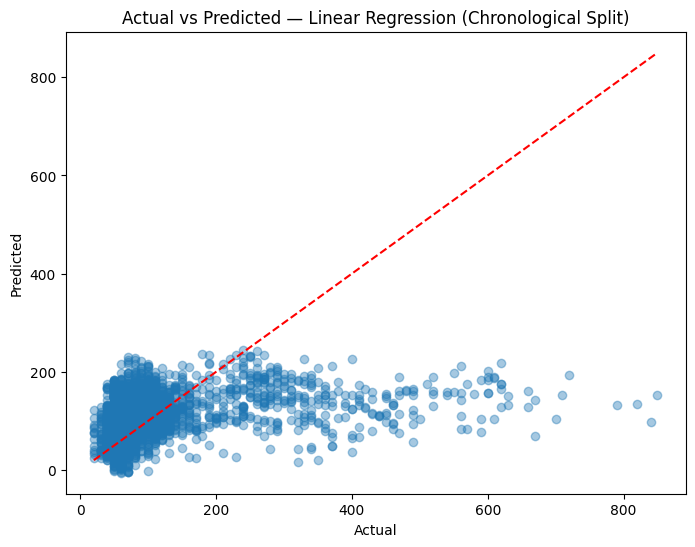

In [1]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, lr_preds, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted — Linear Regression (Chronological Split)")
plt.show()

## 11. Feature Importance (Random Forest, for interpretability)

Even though Linear Regression is the more defensible model for deployment given the extrapolation issue, Random Forest's feature importances and SHAP values still offer useful interpretability into what drives predictions.

In [1]:
rf_model = final_model.named_steps['model']

importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

importance.head(15)

                   Feature  Importance
                      hour    0.170581
                    lights    0.065071
rolling_avg_appliances_24h    0.057722
                        T3    0.052557
                    RH_out    0.035739
                      RH_1    0.032026
                      RH_3    0.031365
                  avg_temp    0.030711
                        T2    0.030365
                      RH_8    0.029618
                        T5    0.028584
                      RH_2    0.027775
                        T8    0.025527
                      RH_7    0.025369
               Press_mm_hg    0.024671


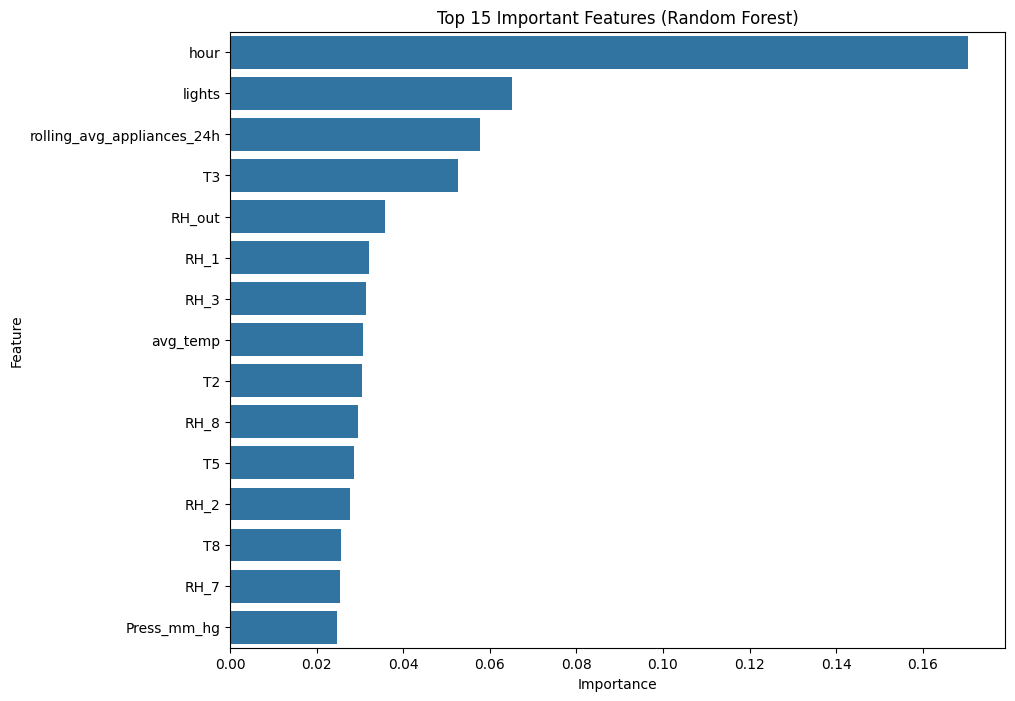

In [1]:
plt.figure(figsize=(10,8))
sns.barplot(data=importance.head(15), x='Importance', y='Feature')
plt.title("Top 15 Important Features (Random Forest)")
plt.show()

## 12. Summary of Findings

| Approach | R² | Notes |
|---|---|---|
| Naive baseline (24h rolling average, no model) | 0.019 | Performance floor |
| Random Forest, regularized, chronological split | -0.658 | Extrapolation failure |
| Linear Regression, chronological split | 0.120 | Best honest result |

**Key takeaways:**

1. The originally reported R²=0.59 (random split) was inflated by temporal data leakage — training and test rows were only minutes apart in a highly correlated time series.
2. A proper chronological split (train on the past, test on a genuine future period) revealed that tree-based models fail badly here, because they cannot extrapolate beyond the value ranges seen in training.
3. Regularizing the Random Forest improved results substantially (R² -2.79 → -0.66) but did not resolve the core issue, confirming a second, independent problem: genuine **non-stationarity** in the relationship between ambient conditions and appliance usage.
4. Adding a recent-usage rolling feature gave a small improvement to Linear Regression (R² 0.107 → 0.120) but did not fundamentally change the picture.
5. **Recommendation**: ambient sensor data (temperature, humidity, time) has a low ceiling for this prediction task. A production system would likely need occupancy sensors or appliance-level usage logs, and/or a scheduled retraining pipeline to keep the model current with shifting household behavior, rather than a single static model trained once.

## 13. Save Final Model

In [1]:
joblib.dump(final_model, "appliance_energy_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully
